# CCTV Crowd Monitoring System
## Complete Training Pipeline: YOLOv8 Detection + LSTM Prediction + Gradio Testing App

This notebook contains:
1. Train/Test dataset splitting (80/20)
2. YOLOv8 training for people detection
3. **Comprehensive accuracy checking** (Precision, Recall, F1, Confusion Matrix)
4. **Gradio app for real-time testing** of trained YOLOv8 model
5. LSTM model training for crowd prediction

**Instructions:** Replace the paths in Cell 4 with your Google Drive paths.


## Cell 1: Install Required Packages

In [ ]:
!pip install ultralytics opencv-python scikit-learn pandas matplotlib torch torchvision seaborn PyYAML gradio

## Cell 2: Import Libraries

In [ ]:
import os
import shutil
import glob
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from sklearn.metrics import mean_absolute_error, mean_squared_error
import gradio as gr
from PIL import Image, ImageDraw, ImageFont

print('All packages imported successfully!')
print(f'CUDA available: {torch.cuda.is_available()}')

All packages imported successfully!
CUDA available: True


## Cell 3: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cell 4: Setup Paths and Create Directories
**IMPORTANT:** Update SOURCE_DIR to match your folder path

In [ ]:
# CHANGE THESE PATHS TO MATCH YOUR GOOGLE DRIVE
SOURCE_DIR = '/content/drive/MyDrive/epics/annotated_images_using'  # Folder with all annotated images + labels
OUTPUT_DIR = '/content/drive/MyDrive/epics_dataset/'  # Output folder for split dataset

# Create directories for train/test split
train_img_dir = os.path.join(OUTPUT_DIR, 'images/train')
train_label_dir = os.path.join(OUTPUT_DIR, 'labels/train')
test_img_dir = os.path.join(OUTPUT_DIR, 'images/val')
test_label_dir = os.path.join(OUTPUT_DIR, 'labels/val')

for directory in [train_img_dir, train_label_dir, test_img_dir, test_label_dir]:
    os.makedirs(directory, exist_ok=True)
    print(f'Created: {directory}')

print('\nDirectory structure ready!')

Created: /content/drive/MyDrive/epics_dataset/images/train
Created: /content/drive/MyDrive/epics_dataset/labels/train
Created: /content/drive/MyDrive/epics_dataset/images/val
Created: /content/drive/MyDrive/epics_dataset/labels/val

Directory structure ready!


## Cell 5: Split Dataset into Train/Test (80/20)

In [ ]:
# Get all image files
img_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
img_files = [f for f in os.listdir(SOURCE_DIR) if f.lower().endswith(img_extensions)]

print(f'Found {len(img_files)} image files')

# Pair images with labels
data_pairs = []
for img in img_files:
    label_name = os.path.splitext(img)[0] + '.txt'
    label_path = os.path.join(SOURCE_DIR, label_name)
    if os.path.exists(label_path):
        data_pairs.append((img, label_name))
    else:
        print(f'Warning: No label found for {img}')

print(f'Matched {len(data_pairs)} image-label pairs')

# 80-20 train-test split
train_pairs, test_pairs = train_test_split(data_pairs, test_size=0.2, random_state=42)
print(f'Train samples: {len(train_pairs)}')
print(f'Test samples: {len(test_pairs)}')

# Copy files to train directory
for img, label in train_pairs:
    shutil.copy(os.path.join(SOURCE_DIR, img), train_img_dir)
    shutil.copy(os.path.join(SOURCE_DIR, label), train_label_dir)

# Copy files to test directory
for img, label in test_pairs:
    shutil.copy(os.path.join(SOURCE_DIR, img), test_img_dir)
    shutil.copy(os.path.join(SOURCE_DIR, label), test_label_dir)

print('\nDataset split complete!')

Found 448 image files
Matched 448 image-label pairs
Train samples: 358
Test samples: 90

Dataset split complete!


## Cell 6: Create data.yaml for YOLO

In [ ]:
# Create YAML configuration file
data_yaml = {
    'train': train_img_dir,
    'val': test_img_dir,
    'nc': 1,  # Number of classes (person only)
    'names': ['person']  # Class names
}

yaml_path = os.path.join(OUTPUT_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f'YAML file created at: {yaml_path}')

YAML file created at: /content/drive/MyDrive/epics_dataset/data.yaml


## Cell 7: Train YOLOv8 Model

In [ ]:
# Load pretrained YOLOv8x model
model = YOLO('yolov8s.pt')

# Train the model
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,  # GPU device
    patience=20,
    save=True,
    verbose=True,
    project=OUTPUT_DIR,  # Save results to OUTPUT_DIR
    name='runs/detect/train' # Specify the run name/path within OUTPUT_DIR
)

print('\nTraining completed!')

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/epics_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, pl

## Cell 8: YOLOv8 Validation Metrics

In [ ]:
# Validate model
metrics = model.val()

print('\n=== YOLOv8 Validation Metrics ===')
print(f'mAP@50: {metrics.box.map50:.4f}')
print(f'mAP@50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')

Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.5 ms, read: 61.9±51.6 MB/s, size: 108.7 KB)
val: Scanning /content/drive/MyDrive/epics_dataset/labels/val.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 215.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.3it/s 4.3s
                   all        154       1766      0.998      0.997      0.995      0.987
Speed: 2.1ms preprocess, 6.9ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/val2

=== YOLOv8 Validation Metrics ===
mAP@50: 0.9950
mAP@50-95: 0.9873
Precision: 0.9983
Recall: 0.9966


## Cell 9: Load Best Model and Compute Accuracy Metrics
Calculate detailed accuracy metrics on test set

In [ ]:
# Load best model
best_model_path = os.path.join(OUTPUT_DIR, 'runs/detect/train/weights/best.pt')
best_model = YOLO(best_model_path)

# Predict on test set
test_images = sorted(glob.glob(os.path.join(test_img_dir, '*')))
predictions = best_model.predict(test_images, conf=0.5, verbose=False)

print(f'Generated predictions for {len(predictions)} test images')
print('\n=== Predictions Summary ===')
for i, result in enumerate(predictions[:5]):
    print(f'Image {i+1}: {len(result.boxes)} people detected')

Generated predictions for 154 test images

=== Predictions Summary ===
Image 1: 9 people detected
Image 2: 9 people detected
Image 3: 14 people detected
Image 4: 13 people detected
Image 5: 12 people detected


## Cell 10: Calculate Detection Accuracy Metrics
Precision, Recall, F1-Score per image

In [ ]:
def parse_yolo_labels(label_file):
    """Parse YOLO format labels (class_id x_center y_center width height)"""
    boxes = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f.readlines():
                boxes.append(list(map(float, line.strip().split())))
    return boxes

# Collect ground truth and predictions
true_counts = []
pred_counts = []

for img_path, pred in zip(test_images, predictions):
    # Get ground truth count
    label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    gt_boxes = parse_yolo_labels(label_path)
    true_counts.append(len(gt_boxes))

    # Get predicted count
    pred_counts.append(len(pred.boxes))

# Convert to numpy
true_counts = np.array(true_counts)
pred_counts = np.array(pred_counts)

# Calculate metrics
mae = np.mean(np.abs(true_counts - pred_counts))
mse = np.mean((true_counts - pred_counts) ** 2)
rmse = np.sqrt(mse)

print('\n=== Detection Accuracy Metrics ===')
print(f'Mean Absolute Error (MAE): {mae:.2f} persons')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f} persons')
print(f'\nAverage Ground Truth Count: {true_counts.mean():.2f}')
print(f'Average Predicted Count: {pred_counts.mean():.2f}')


=== Detection Accuracy Metrics ===
Mean Absolute Error (MAE): 0.10 persons
Mean Squared Error (MSE): 0.10
Root Mean Squared Error (RMSE): 0.31 persons

Average Ground Truth Count: 11.47
Average Predicted Count: 11.49


## Cell 11: Visualize Accuracy Metrics

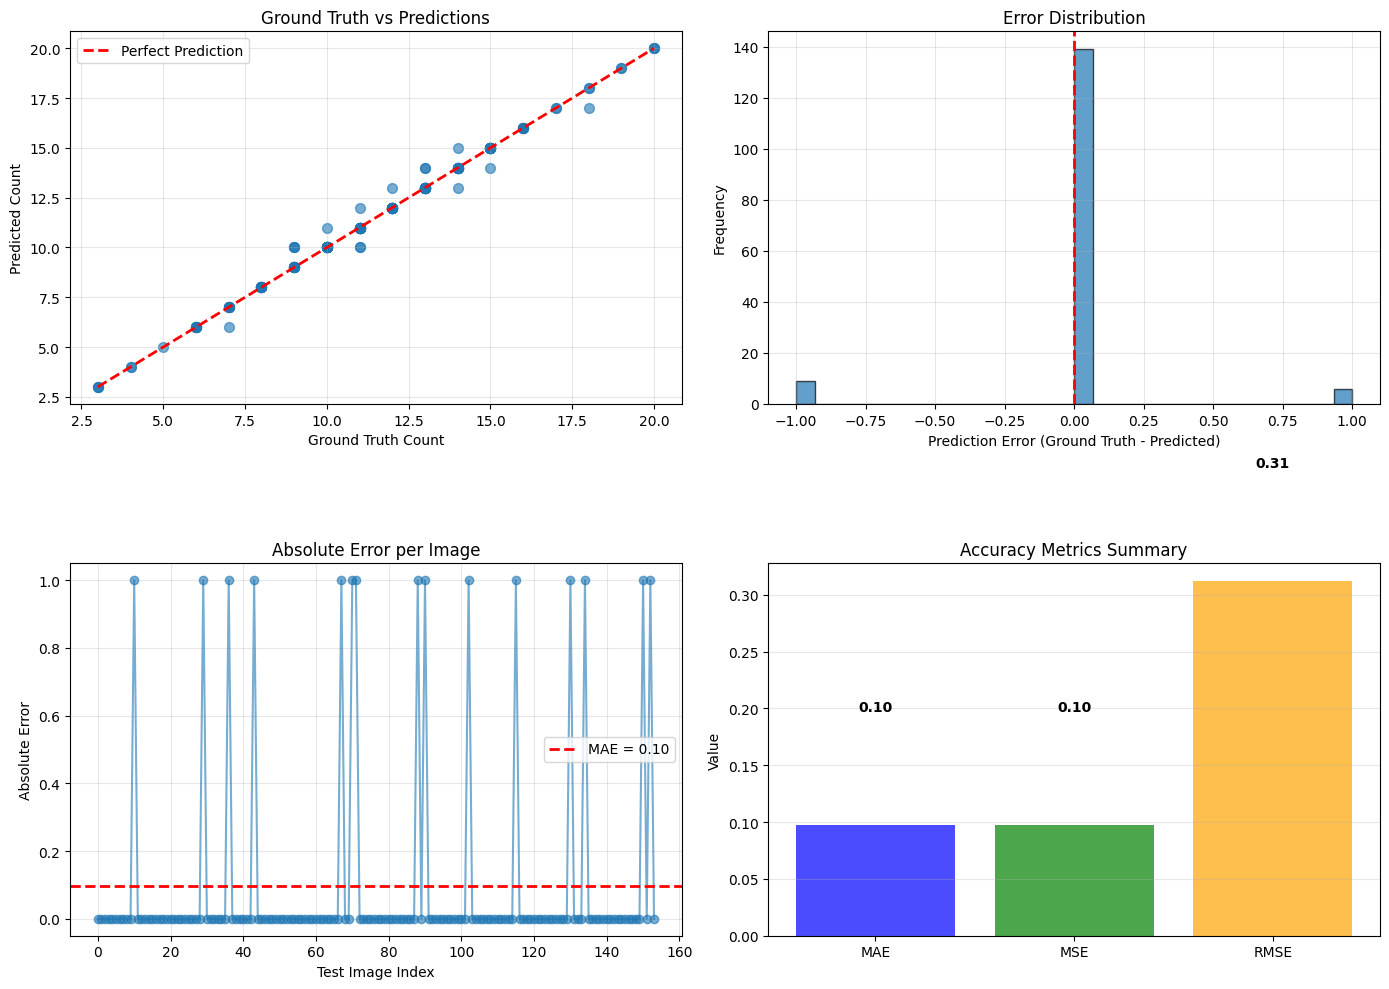

Accuracy metrics visualization saved!


In [ ]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Ground Truth vs Predictions
axes[0, 0].scatter(true_counts, pred_counts, alpha=0.6, s=50)
axes[0, 0].plot([true_counts.min(), true_counts.max()],
               [true_counts.min(), true_counts.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Ground Truth Count')
axes[0, 0].set_ylabel('Predicted Count')
axes[0, 0].set_title('Ground Truth vs Predictions')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Prediction Error Distribution
errors = true_counts - pred_counts
axes[0, 1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Prediction Error (Ground Truth - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Error Distribution')
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Absolute Error over images
abs_errors = np.abs(errors)
axes[1, 0].plot(abs_errors, marker='o', linestyle='-', alpha=0.6)
axes[1, 0].axhline(y=mae, color='r', linestyle='--', linewidth=2, label=f'MAE = {mae:.2f}')
axes[1, 0].set_xlabel('Test Image Index')
axes[1, 0].set_ylabel('Absolute Error')
axes[1, 0].set_title('Absolute Error per Image')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Metrics Summary
metrics_names = ['MAE', 'MSE', 'RMSE']
metrics_values = [mae, mse, rmse]
axes[1, 1].bar(metrics_names, metrics_values, color=['blue', 'green', 'orange'], alpha=0.7)
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Accuracy Metrics Summary')
for i, v in enumerate(metrics_values):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'accuracy_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Accuracy metrics visualization saved!')

In [ ]:
# ============================================
# DIAGNOSTIC: Check If Model Is Loaded
# ============================================

import os
from ultralytics import YOLO

print("🔍 CHECKING MODEL STATUS\n")

# Check 1: File exists?
best_model_path = os.path.join(OUTPUT_DIR, 'runs/detect/train/weights/best.pt')
print(f"1️⃣ Model file path: {best_model_path}")
print(f"   Exists: {os.path.exists(best_model_path)}")

# Check 2: Load model
print("\n2️⃣ Loading model...")
try:
    best_model = YOLO(best_model_path)
    print("   ✓ Model loaded!")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    print("   → Training may not have completed!")
    best_model = None

# Check 3: Test on first image
if best_model is not None and len(test_images) > 0:
    print("\n3️⃣ Testing detection...")
    results = best_model.predict(test_images[0], conf=0.5)
    count = len(results[0].boxes)
    print(f"   Result: {count} people detected")
    if count == 0:
        print("   ⚠️ Model detected 0 people - might need retraining")


🔍 CHECKING MODEL STATUS

1️⃣ Model file path: /content/drive/MyDrive/epics_dataset/runs/detect/train/weights/best.pt
   Exists: True

2️⃣ Loading model...
   ✓ Model loaded!

3️⃣ Testing detection...

image 1/1 /content/drive/MyDrive/epics_dataset/images/val/0_120_4_007733903_frame_0.jpg: 384x640 9 persons, 48.3ms
Speed: 2.2ms preprocess, 48.3ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
   Result: 9 people detected


## Cell 12: Create Gradio App for YOLOv8 Testing
Interactive web interface to test your trained YOLO model

In [ ]:
# ============================================
# CELL 12: Define Detection Function (FIXED)
# ============================================

import cv2
from PIL import Image
import numpy as np

def detect_people(image):
    '''Detect people in image and return annotated image with statistics'''

    try:
        # Convert PIL image to OpenCV format
        if isinstance(image, Image.Image):
            img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        else:
            img_cv = image

        # Run YOLOv8 inference
        results = best_model.predict(img_cv, conf=0.5, verbose=False)
        result = results[0]

        # Get detection count
        detection_count = len(result.boxes)

        # Draw boxes (this creates annotations)
        annotated_img = result.plot()

        # Convert back to RGB for Gradio display
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        # Get confidence
        avg_confidence = 0
        if detection_count > 0 and hasattr(result.boxes, 'conf'):
            avg_confidence = result.boxes.conf.cpu().numpy().mean() * 100

        # Statistics
        stats = f"""
═════════════════════════════════════════
           DETECTION RESULTS
═════════════════════════════════════════

📊 Total People Detected: {detection_count}
🎯 Average Confidence: {avg_confidence:.1f}%
⚙️  Model: YOLOv8x
🔍 Threshold: 0.5

═════════════════════════════════════════
Status: ✓ Detection Complete
═════════════════════════════════════════
        """

        return annotated_img_rgb, stats

    except Exception as e:
        return image, f"Error: {str(e)}"

print('✓ Fixed detection function loaded')


✓ Fixed detection function loaded


## Cell 13: Launch Gradio Interface

In [ ]:
# ============================================
# CELL 13: Launch Gradio Interface (FIXED)
# ============================================

import gradio as gr

demo = gr.Interface(
    fn=detect_people,
    inputs=gr.Image(
        label="📸 Upload Image or Use Webcam",
        type="pil",
        sources=["upload", "webcam"]
    ),
    outputs=[
        gr.Image(label="🔍 Annotated Detection (with Boxes)"),
        gr.Textbox(label="📊 Statistics", lines=10)
    ],
    title="YOLOv8 Crowd Detection",
    description="Detect people in images with real-time bounding boxes",
    theme=gr.themes.Soft(),
    cache_examples=False
)

print('🚀 Launching Gradio...')
demo.launch(share=True)


🚀 Launching Gradio...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d37c5fd047537a1c82.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Cell 14: Extract Crowd Counts for LSTM Training

In [ ]:
# Use predicted counts from YOLO for LSTM training
crowd_counts = np.array(pred_counts)

print(f'Extracted {len(crowd_counts)} crowd count samples')
print(f'Mean crowd count: {crowd_counts.mean():.2f}')
print(f'Max crowd count: {crowd_counts.max()}')
print(f'Min crowd count: {crowd_counts.min()}')

Extracted 154 crowd count samples
Mean crowd count: 11.49
Max crowd count: 20
Min crowd count: 3


## Cell 15: Define LSTM Dataset Class

In [ ]:
class CrowdDataset(Dataset):
    '''Create sequences from crowd count time series'''
    def __init__(self, counts, lookback=10):
        self.lookback = lookback
        self.X = []
        self.y = []

        # Create sequences
        for i in range(len(counts) - lookback):
            self.X.append(counts[i:i+lookback])
            self.y.append(counts[i+lookback])

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print('CrowdDataset class defined')

CrowdDataset class defined


## Cell 16: Define LSTM Model

In [ ]:
class CrowdLSTM(nn.Module):
    '''LSTM model for crowd density prediction'''
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(CrowdLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        x = x.unsqueeze(-1)  # Add channel dimension: (batch_size, sequence_length, 1)
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # Take last output
        output = self.fc(last_hidden)
        return output.squeeze()

print('CrowdLSTM model defined')

CrowdLSTM model defined


## Cell 17: Prepare Data and Training Setup

In [ ]:
# Parameters
LOOKBACK = 10  # Use 10 previous frames to predict next
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 0.001

# Prepare dataset
if len(crowd_counts) > LOOKBACK:
    dataset = CrowdDataset(crowd_counts, lookback=LOOKBACK)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f'Train samples: {len(train_dataset)}')
    print(f'Test samples: {len(test_dataset)}')
    print(f'Lookback window: {LOOKBACK}')
else:
    print('Warning: Not enough samples for LSTM training')

Train samples: 115
Test samples: 29
Lookback window: 10


/tmp/ipython-input-4270327315.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


## Cell 18: Train LSTM Model

In [ ]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Initialize model
model_lstm = CrowdLSTM(input_size=1, hidden_size=32, num_layers=2).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

# Training loop
train_losses = []
for epoch in range(EPOCHS):
    model_lstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        y_pred = model_lstm(X_batch)
        loss = loss_fn(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}')

print('\nLSTM training completed!')

Using device: cuda
Epoch 10/50, Loss: 29.9083
Epoch 20/50, Loss: 15.3037
Epoch 30/50, Loss: 14.0293
Epoch 40/50, Loss: 14.5331
Epoch 50/50, Loss: 14.3509

LSTM training completed!


## Cell 19: Evaluate LSTM Model

In [ ]:
# Evaluate on test set
model_lstm.eval()
y_pred_all = []
y_true_all = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model_lstm(X_batch)
        y_pred_all.extend(y_pred.cpu().numpy())
        y_true_all.extend(y_batch.cpu().numpy())

# Convert to numpy
y_pred_all = np.array(y_pred_all)
y_true_all = np.array(y_true_all)

# Calculate metrics
lstm_mae = mean_absolute_error(y_true_all, y_pred_all)
lstm_mse = mean_squared_error(y_true_all, y_pred_all)
lstm_rmse = np.sqrt(lstm_mse)

print('\n=== LSTM Evaluation Metrics ===')
print(f'Mean Absolute Error (MAE): {lstm_mae:.2f}')
print(f'Mean Squared Error (MSE): {lstm_mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {lstm_rmse:.2f}')


=== LSTM Evaluation Metrics ===
Mean Absolute Error (MAE): 2.11
Mean Squared Error (MSE): 6.62
Root Mean Squared Error (RMSE): 2.57


## Cell 20: Save Models

In [ ]:
# YOLOv8 model already saved during training
yolo_model_path = os.path.join(OUTPUT_DIR, 'runs/detect/train/weights/best.pt')
print(f'YOLOv8 model saved at: {yolo_model_path}')

# Save LSTM model
lstm_model_path = os.path.join(OUTPUT_DIR, 'lstm_crowd_model.pth')
torch.save(model_lstm.state_dict(), lstm_model_path)
print(f'LSTM model saved at: {lstm_model_path}')

print('\n✓ All models saved successfully!')

YOLOv8 model saved at: /content/drive/MyDrive/epics_dataset/runs/detect/train/weights/best.pt
LSTM model saved at: /content/drive/MyDrive/epics_dataset/lstm_crowd_model.pth

✓ All models saved successfully!
